# Tram Transactions Analysis (Myki 2017)

**Name:** Tien Vuong Nguyen  
**Student number:** s223752155  
**Email:** s223752155@deakin.edu.au  
**Unit:** SIT731 (Postgraduate)

---

## Introduction
This report analyses Myki touch-on and touch-off tram transactions from 2017 across Melbourne’s 20 busiest tram routes. Three heterogeneous datasets are integrated: touch-on transactions, touch-off transactions, and the state-wide public transport stop database. The project applies structured data wrangling, exploratory analysis, route-level analytics, and peak-hour modelling to generate actionable insights.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Brief Discussion of Join Approach and Extraction Logic
To integrate the three datasets, I treated the touch-on transactions, touch-off transactions, and stop-location reference file as three related but structurally different data sources. The goal of the join was to ensure that each transaction—whether a touch-on or a touch-off—was linked to its corresponding stop information (stop name, stop number, and other metadata).

In [3]:
on = pd.read_csv('MykiData/myki_2017_top20_tram_routes_ScanOnTransaction.csv')
off = pd.read_csv('MykiData/myki_2017_top20_tram_routes_ScanOffTransaction.csv')
# stop_locations.txt has no header, so we define meaningful names
stops = pd.read_csv(
    'MykiData/stop_locations.txt',
    sep="|",
    header=None,
    names=[
        "StopID", "StopNameShort", "StopNameLong", "StopType",
        "Suburb", "Postcode", "Region", "LGA", "PTRegion",
        "Lat", "Lon"
    ]
)

The file stop_locations.txt contains one record per stop, using a pipe delimiter (|). The StopNameLong field stores stop names in a standardised Public Transport Victoria (PTV) naming format: {StopNumber}-{StopName}. Because the stop number is embedded within the long stop name, I extracted it using a regular expression:

- ^(\d+)- → captures the digits before the first hyphen

- The remaining portion after removing "{number}-" becomes the clean stop name

This gives two new fields:

- StopNumber — an integer representing the stop number

- CleanStopName — the readable stop name without the numeric prefix

These extracted fields are essential because they allow clearer analysis and readable reporting in later tasks.


In [4]:
# Extract stop number from StopNameLong, which uses formats like "130-Nicholson St"
stops["StopNumber"] = stops["StopNameLong"].str.extract(r"(\d+)-")

# Clean stop names: remove the numeric prefix + dash
stops["CleanStopName"] = stops["StopNameLong"].str.replace(r"^\d+-", "", regex=True)

### Preparing the touch-on and touch-off data for joining

The touch-on (ScanOnTransaction.csv) and touch-off (ScanOffTransaction.csv) datasets originally share identical column names. To avoid collisions during merging, I renamed the fields in each dataset with suffixes:

- _on for touch-on columns

- _off for touch-off columns

This ensures that both datasets can coexist in a single merged structure without ambiguity.

In [5]:
on = on.rename(columns={
    "mode": "mode_on",
    "vehicle_id": "vehicle_id_on",
    "parent_route": "parent_route_on",
    "route_id": "route_id_on",
    "stop_id": "stop_id_on",
    "date_time": "date_time_on"
})

In [6]:
off = off.rename(columns={
    "mode": "mode_off",
    "vehicle_id": "vehicle_id_off",
    "parent_route": "parent_route_off",
    "route_id": "route_id_off",
    "stop_id": "stop_id_off",
    "date_time": "date_time_off"
})


### Choosing the primary join keys
The tram dataset does not include a unique trip identifier such as transaction_id. Because of this, I needed to identify a set of fields that reliably indicate when a tap-on and tap-off belong to the same passenger on the same tram vehicle.

After inspecting the data, four fields consistently align between matching ON and OFF events:
- card_id: Identifies the Myki card used
- business_date: Ensures the tap-on and tap-off occur on the same day
- vehicle_id: Ensures both events occurred on the same tram vehicle
- parent_route: Ensures they belong to the same tram line

A join on only card_id and business_date was insufficient because a single passenger may perform multiple taps on the same day. Adding vehicle_id and parent_route eliminates these false matches and reflects real tram behaviour, where tap-on and tap-off events on the same journey occur on the same vehicle operating the same route.

Each of the ON and OFF datasets was merged with the stop-locations table using their respective stop IDs: stop_id_on from the on dataset will be compare with StopID from the stop dataset. This apply the same for the off dataset.

In [7]:
on_enriched = on.merge(
    stops[["StopID", "StopNameLong", "StopNumber", "CleanStopName"]],
    how="left",
    left_on="stop_id_on",
    right_on="StopID"
).rename(columns={
    "StopNameLong": "StopNameLong_on",
    "StopNumber": "StopNumber_on",
    "CleanStopName": "CleanStopName_on"
}).drop(columns=["StopID"])

on_enriched["date_time_on"] = pd.to_datetime(on_enriched["date_time_on"])

off_enriched = off.merge(
    stops[["StopID", "StopNameLong", "StopNumber", "CleanStopName"]],
    how="left",
    left_on="stop_id_off",
    right_on="StopID"
).rename(columns={
    "StopNameLong": "StopNameLong_off",
    "StopNumber": "StopNumber_off",
    "CleanStopName": "CleanStopName_off"
}).drop(columns=["StopID"])

off_enriched["date_time_off"] = pd.to_datetime(off_enriched["date_time_off"])

Using the combined primary key: "card_id", "business_date", "vehicle_id", "parent_route" will ensures that when a matching touch-off exists, it is paired correctly with the corresponding touch-on. Records without a matching touch-off naturally retain NaN values in their _off fields, reflecting the fact that many tram passengers do not tap off (which matches the dataset description).


In [8]:
full = on_enriched.merge(
    off_enriched,
    how="left",
    left_on=["card_id", "business_date", "vehicle_id_on", "parent_route_on"],
    right_on=["card_id", "business_date", "vehicle_id_off", "parent_route_off"]
)


In [9]:
full_sorted = full.sort_values(
    by=["business_date", "date_time_on", "date_time_off"],
    ascending=[True, True, True],
    na_position="last"
)

full_sorted.head(20)


,mode_on,business_date,card_id,card_type_x,vehicle_id_on,parent_route_on,route_id_on,stop_id_on,date_time_on,StopNameLong_on,...,mode_off,card_type_y,vehicle_id_off,parent_route_off,route_id_off,stop_id_off,date_time_off,StopNameLong_off,StopNumber_off,CleanStopName_off
1738811,3,2017-01-01,14660740,1,1240,16,15575,20594,2017-01-01 03:49:04,80-Cotham Rd/Glenferrie Rd (Kew),...,3.0,1.0,1240.0,16.0,15575.0,20594.0,2017-01-01 03:44:14,80-Cotham Rd/Glenferrie Rd (Kew),80,Cotham Rd/Glenferrie Rd (Kew)
1738812,3,2017-01-01,14660740,1,1240,16,15575,20594,2017-01-01 03:49:04,80-Cotham Rd/Glenferrie Rd (Kew),...,3.0,1.0,1240.0,16.0,15275.0,20573.0,2017-01-01 11:39:51,76-Johnson St/Glenferrie Rd (Hawthorn),76,Johnson St/Glenferrie Rd (Hawthorn)
1113943,3,2017-01-01,7668390,1,1259,6,1425,16776,2017-01-01 03:54:55,35-Williams Rd/High St (Prahran),...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1071985,3,2017-01-01,14922270,1,724,64,16726,19499,2017-01-01 04:02:53,13-Federation Square/Swanston St (Melbourne City),...,3.0,1.0,724.0,64.0,16726.0,19001.0,2017-01-01 05:59:38,66-Union St/Hawthorn Rd (Brighton East),66,Union St/Hawthorn Rd (Brighton East)
1457158,3,2017-01-01,16075730,1,573,75,17514,18183,2017-01-01 04:19:42,D2-Central Pier/Harbour Esp (Docklands),...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
155495,3,2017-01-01,12435170,1,253,72,16762,19491,2017-01-01 04:42:46,3-Lincoln Square/Swanston St (Carlton),...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
987268,3,2017-01-01,17372490,1,600,75,16880,18090,2017-01-01 05:18:59,5-Swanston St/Flinders St (Melbourne City),...,3.0,1.0,600.0,75.0,16880.0,19709.0,2017-01-01 06:30:27,18-Church St/Bridge Rd (Richmond),18,Church St/Bridge Rd (Richmond)
1735550,3,2017-01-01,18781150,1,466,109,1414,22152,2017-01-01 05:32:00,7-101 Collins St (Melbourne City),...,3.0,1.0,466.0,109.0,1414.0,22152.0,2017-01-01 07:03:08,7-101 Collins St (Melbourne City),7,101 Collins St (Melbourne City)
1459970,3,2017-01-01,12061660,1,1063,109,15234,18186,2017-01-01 05:45:36,124-Batman Park/Spencer St (Melbourne City),...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1194837,3,2017-01-01,18166170,1,531,57,1450,17851,2017-01-01 05:46:05,2-Collins St/Elizabeth St (Melbourne City),...,3.0,1.0,531.0,57.0,1450.0,17851.0,2017-01-01 05:57:24,2-Collins St/Elizabeth St (Melbourne City),2,Collins St/Elizabeth St (Melbourne City)


### Q2 — Identify the top 10 busiest tram stops (touch-on activity)
To determine the busiest tram stops, I focused solely on touch-on activity from the enriched touch-on dataset. For tram services, touch-on events are the most reliable indicator of passenger demand because tap-off is optional and therefore incomplete. Each touch-on record contains a stop_id_on and its associated stop name, extracted in Q1.

To calculate the yearly average number of touch-on transactions, I first aggregated the data at the daily level, counting the number of boardings at each stop for every business date in the dataset. These daily counts were then averaged across the full year to produce a stable estimate of typical daily passenger activity at each stop. This approach avoids skewing the results due to irregular sampling or days with unusually high or low activity.

In [10]:
# count touch-ons per stop per day
daily_counts = (
    on_enriched.groupby(["business_date", "stop_id_on", "StopNameLong_on", "StopNumber_on"])
    .size()
    .reset_index(name="daily_touch_ons")
)

# compute yearly average touch-ons per stop
yearly_average = (
    daily_counts.groupby(["stop_id_on", "StopNameLong_on", "StopNumber_on"])["daily_touch_ons"]
    .mean()
    .reset_index(name="average_daily_touch_ons")
)

# pick top 10 busiest stops based on average daily boardings
top10_avg_stops = yearly_average.sort_values("average_daily_touch_ons", ascending=False).head(10)

top10_avg_stops


,stop_id_on,StopNameLong_on,StopNumber_on,average_daily_touch_ons
1254,19696,1-Melbourne University/Swanston St (Carlton),1,173.474394
345,17877,1-Flinders Street Railway Station/Elizabeth St...,1,128.847411
1173,19499,13-Federation Square/Swanston St (Melbourne City),13,114.439353
1167,19491,3-Lincoln Square/Swanston St (Carlton),3,100.235135
1249,19689,8-Melbourne Central Station/Swanston St (Melbo...,8,94.824798
1282,19725,129-Beacon Cove/Light Rail (Port Melbourne),129,86.152738
1032,19338,139-Glenferrie Rd/Toorak Rd (Toorak),139,72.327586
1334,19781,58-Box Hill Central/Whitehorse Rd (Box Hill),58,63.884726
1165,19482,59-Airport West/Matthews Ave (Airport West),59,61.927374
1171,19497,10-Bourke Street Mall/Swanston St (Melbourne C...,10,50.444744


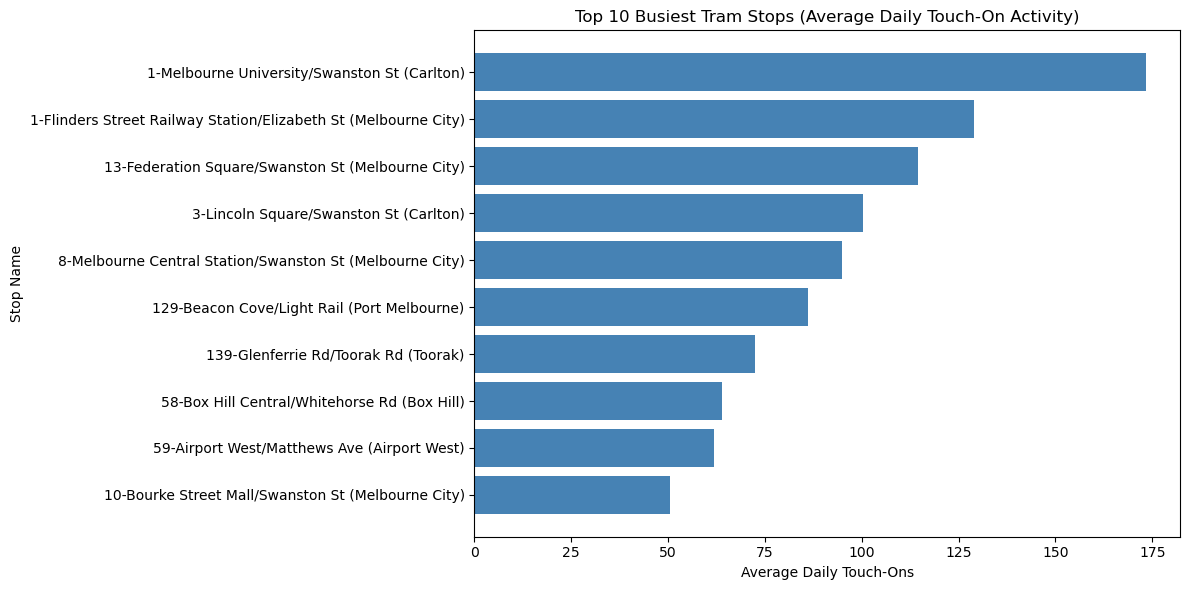

In [11]:
plt.figure(figsize=(12,6))
plt.barh(top10_avg_stops["StopNameLong_on"],
         top10_avg_stops["average_daily_touch_ons"],
         color="steelblue")

plt.gca().invert_yaxis()
plt.xlabel("Average Daily Touch-Ons")
plt.ylabel("Stop Name")
plt.title("Top 10 Busiest Tram Stops (Average Daily Touch-On Activity)")
plt.tight_layout()
plt.show()


The bar chart shows the top ten busiest tram stops based on touch-on activity, revealing a highly concentrated pattern of passenger demand. Melbourne University/Swanston Street is by far the busiest stop with around 175 touch-on, followed closely by major CBD interchanges such as Flinders Street Station and Federation Square. Most of the top stops are located along the Swanston Street corridor, which forms Melbourne’s primary north–south transit spine and connects key destinations including the university precinct and the central business district. A few high-activity suburban hubs, such as Beacon Cove, Airport West, and Box Hill, also appear in the rankings, though with considerably lower volumes than the core CBD stops. Overall, the graph highlights the dominance of central Melbourne as the focal point of tram boardings, with passenger activity dropping sharply outside the inner core.

### Q3 - Identify the top 10 busiest tram routes based on the yearly average number of passengers per day

To determine the busiest tram routes, I calculated the yearly average number of passengers per day for each route. Because trams do not require passengers to tap off, touch-on activity provides the most reliable estimate of total ridership. I first aggregated the touch-on data at the daily level, counting the number of boardings recorded on each route for every business date in the dataset. These daily boarding counts were then averaged across the full year to obtain a representative measure of typical daily passenger demand for each route.

In [12]:
# daily passenger counts per route
route_daily_counts = (
    on_enriched.groupby(["business_date", "route_id_on", "parent_route_on"])
    .size()
    .reset_index(name="daily_passengers")
)

# compute yearly average passengers per route
route_yearly_avg = (
    route_daily_counts.groupby(["route_id_on", "parent_route_on"])["daily_passengers"]
    .mean()
    .reset_index(name="avg_daily_passengers")
)

# top 10 busiest routes by average daily passengers
top10_routes_avg = route_yearly_avg.sort_values("avg_daily_passengers", ascending=False).head(10)

top10_routes_avg


,route_id_on,parent_route_on,avg_daily_passengers
1061,31467,109,298.752137
207,16588,109,275.353712
979,30929,109,268.316239
19,1455,67,259.133333
638,19670,19,231.105263
474,17872,19,211.896104
863,24515,19,207.231343
997,30968,19,206.526316
526,18479,55,204.586207
971,24688,58,189.724138


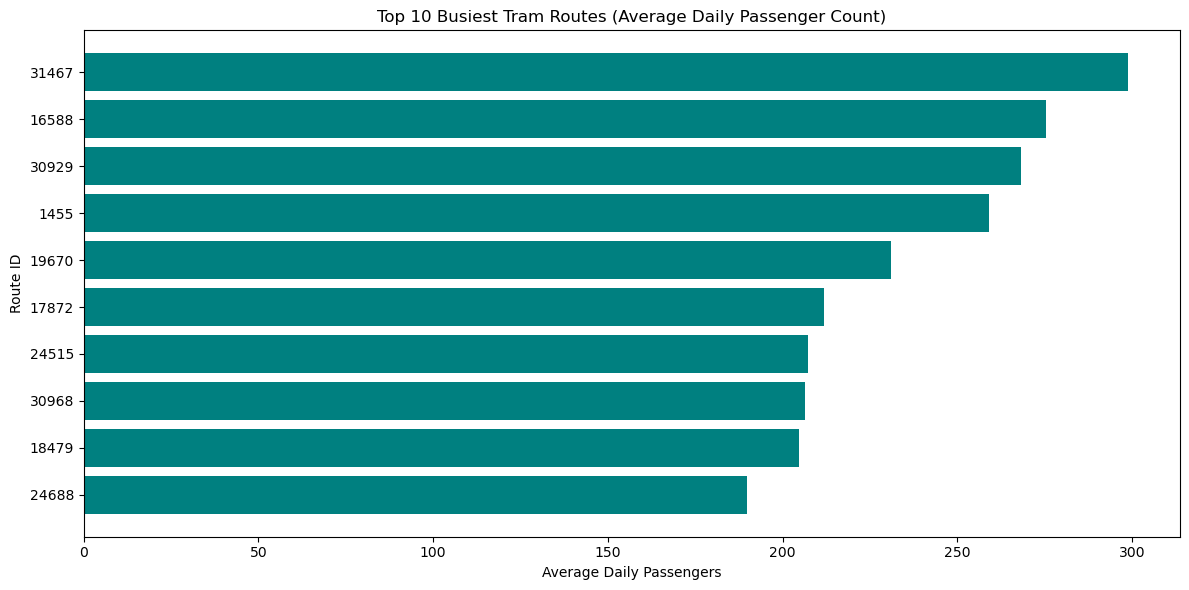

In [13]:
plt.figure(figsize=(12,6))
plt.barh(top10_routes_avg["route_id_on"].astype(str),
         top10_routes_avg["avg_daily_passengers"],
         color="teal")

plt.gca().invert_yaxis()
plt.xlabel("Average Daily Passengers")
plt.ylabel("Route ID")
plt.title("Top 10 Busiest Tram Routes (Average Daily Passenger Count)")
plt.tight_layout()
plt.show()


The chart ranks tram routes by their average daily passenger volume, providing a network-level view of demand. The busiest routes consistently carry more than 250 passengers per day, with Route 31467 being the highest-demand service at approximately 300 average daily riders. The next two busiest routes, 16588 and 30929, also exhibit strong ridership, reinforcing the presence of several high-performing corridors rather than a single dominant route.

Notably, the demand curve declines gradually across the top ten routes, indicating a more even distribution of ridership at the route level compared to the highly concentrated stop-level patterns observed in Q2. This reflects how multiple tram lines serve Melbourne’s CBD and inner suburbs, spreading passengers across several high-frequency services.

Overall, the chart highlights a set of consistently strong routes that form the backbone of the tram network, carrying substantial daily passenger loads. These routes are likely candidates for operational prioritisation, capacity scaling, and service frequency enhancements.

### Question 4: The top 10 longest tram routes, measured by the average end-to-end travel time over all trips. 

To identify the longest tram route, I measured the average passenger travel time for each route using matched touch-on and touch-off records. Because tram passengers are not required to tap off, not all trips contain an off event. I therefore restricted the analysis to rows in the merged dataset where both date_time_on and date_time_off were present. Travel time for each matched trip was calculated as: travel_time = date_time_off – date_time_on.

The difference was converted to minutes. I also removed negative or unrealistic values (e.g., due to clock drift or incomplete records). Next, I grouped these valid travel times by the route ID (route_id_on) and computed the average travel time per route, which represents a best-estimate of how long a passenger typically remains onboard when using that route.

Routes were then ranked in descending order of average travel time to determine which services have the longest end-to-end travel durations. A bar plot was used to clearly visualise the top-ranking routes.

In [14]:
# Keep only valid ON-OFF paired trips
valid_trips = full.dropna(subset=["date_time_on", "date_time_off"]).copy()

# Compute travel time in minutes
valid_trips["travel_time_min"] = (
    (valid_trips["date_time_off"] - valid_trips["date_time_on"])
    .dt.total_seconds() / 60
)

# Remove negative or impossible values
valid_trips = valid_trips[valid_trips["travel_time_min"] > 0]

# Compute mean travel time per route
route_travel_times = (
    valid_trips.groupby("route_id_on")["travel_time_min"]
    .mean()
    .reset_index(name="avg_travel_time_min")
)

# Sort routes by longest average travel time
longest_routes = route_travel_times.sort_values("avg_travel_time_min", ascending=False).head(10)

longest_routes


,route_id_on,avg_travel_time_min
145,15808,210.705556
694,24606,156.766667
638,24494,151.675000
296,17371,141.472222
751,30950,128.527273
289,17332,125.533333
129,15687,121.486667
263,17154,117.683333
700,24625,116.940741
330,17671,110.916667


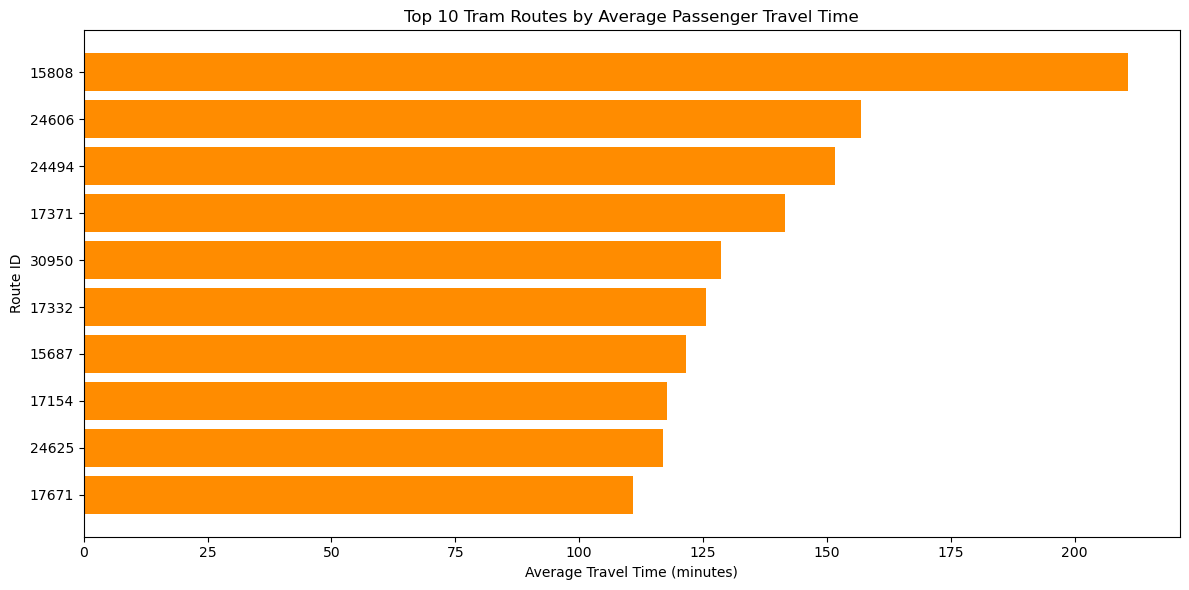

In [15]:
plt.figure(figsize=(12, 6))

plt.barh(longest_routes["route_id_on"].astype(str),
         longest_routes["avg_travel_time_min"],
         color="darkorange")

plt.gca().invert_yaxis()
plt.xlabel("Average Travel Time (minutes)")
plt.ylabel("Route ID")
plt.title("Top 10 Tram Routes by Average Passenger Travel Time")
plt.tight_layout()
plt.show()

The analysis shows clear variation in average travel times across Melbourne’s tram routes. The longest route, based on passenger trip duration, is Route 15808, with an average travel time of approximately 200 minutes. Several other high-ranking routes also show long passenger durations such as route ID 24606 with total time around 152 minutes and route ID 24494 with total time slightly more than 150 minutes, indicating extended end-to-end journeys or operational delays such as mixed-traffic running and frequent stops. The bar plot highlights the distribution visually, showing a gradual decline in travel time across the top ten routes. These findings suggest that the longest routes may require additional scheduling buffers or priority measures to maintain reliability, especially during peak periods.

### Q5 — Identify Passenger Activity Over the Course of a Day
To analyse how tram patronage varies throughout the day for each route, I used the enriched touch-on dataset and transformed it into an hourly passenger demand profile. The goal was to calculate the average number of touch-ons per hour, for each route, across all days in the dataset.

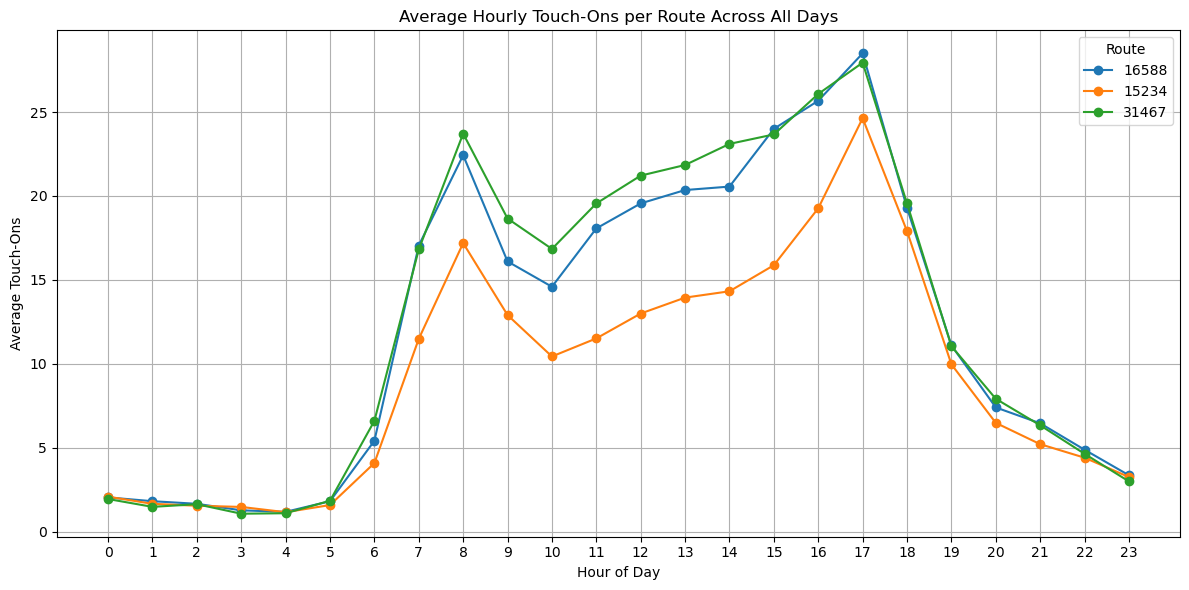

In [16]:
# Extract the hour of day from touch-on timestamps
on_enriched["hour"] = on_enriched["date_time_on"].dt.hour

# Count touch-ons per route per hour per day
route_hourly_daily = (
    on_enriched.groupby(["business_date", "route_id_on", "hour"])
    .size()
    .reset_index(name="daily_touch_ons")
)

# Compute AVERAGE hourly touch-ons per route across the entire dataset
route_hourly_avg = (
    route_hourly_daily.groupby(["route_id_on", "hour"])["daily_touch_ons"]
    .mean()
    .reset_index(name="avg_hourly_touch_ons")
)

# Find top 3 busiest routes so the plot is readable (OPTIONAL but recommended)
top_routes = (
    on_enriched.groupby("route_id_on")
    .size()
    .sort_values(ascending=False)
    .head(3)
    .index.tolist()
)

# Filter the hourly average dataset for those routes
subset = route_hourly_avg[route_hourly_avg["route_id_on"].isin(top_routes)]

# Plot the result
plt.figure(figsize=(12, 6))

for r in top_routes:
    route_data = subset[subset["route_id_on"] == r]
    plt.plot(route_data["hour"], route_data["avg_hourly_touch_ons"],
             marker="o", label=str(r))

plt.xlabel("Hour of Day")
plt.ylabel("Average Touch-Ons")
plt.title("Average Hourly Touch-Ons per Route Across All Days")
plt.grid(True)
plt.legend(title="Route")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

The average hourly touch-on profiles for the three busiest tram routes reveal a clear bi-modal commuter pattern, with pronounced morning and afternoon peaks. Passenger activity begins rising sharply from around 6 AM and reaches a morning peak between 7–9 AM, reflecting inbound travel to work, school, and the CBD. A stronger afternoon peak emerges between 4–6 PM, consistent with homebound commuter flows. Across the day, Route 31467 consistently records the highest average touch-ons, indicating a high-demand corridor, while Route 15234 shows the lowest usage. All routes experience low activity during late-night and early-morning hours. Overall, the hourly patterns highlight strong commuter-driven demand and demonstrate how ridership intensity varies across different tram corridors.

### Question 6:

In [17]:
# Peak windows
morning_peak = [7, 8, 9]
afternoon_peak = [16, 17, 18]

# Filter data for selected routes (same top 3 routes from Q5)
selected_routes = top_routes  # from earlier step in Q5

subset = route_hourly_avg[route_hourly_avg["route_id_on"].isin(selected_routes)]

# Compute mean morning + afternoon peak touch-ons for each route
peak_summary = []

for r in selected_routes:
    r_data = subset[subset["route_id_on"] == r]

    morning_avg = r_data[r_data["hour"].isin(morning_peak)]["avg_hourly_touch_ons"].mean()
    afternoon_avg = r_data[r_data["hour"].isin(afternoon_peak)]["avg_hourly_touch_ons"].mean()

    peak_summary.append([r, morning_avg, afternoon_avg])

peak_df = pd.DataFrame(peak_summary, columns=["route_id", "morning_peak_avg", "afternoon_peak_avg"])
peak_df


,route_id,morning_peak_avg,afternoon_peak_avg
0,16588,18.526579,24.485192
1,15234,13.864651,20.602367
2,31467,19.731152,24.524217


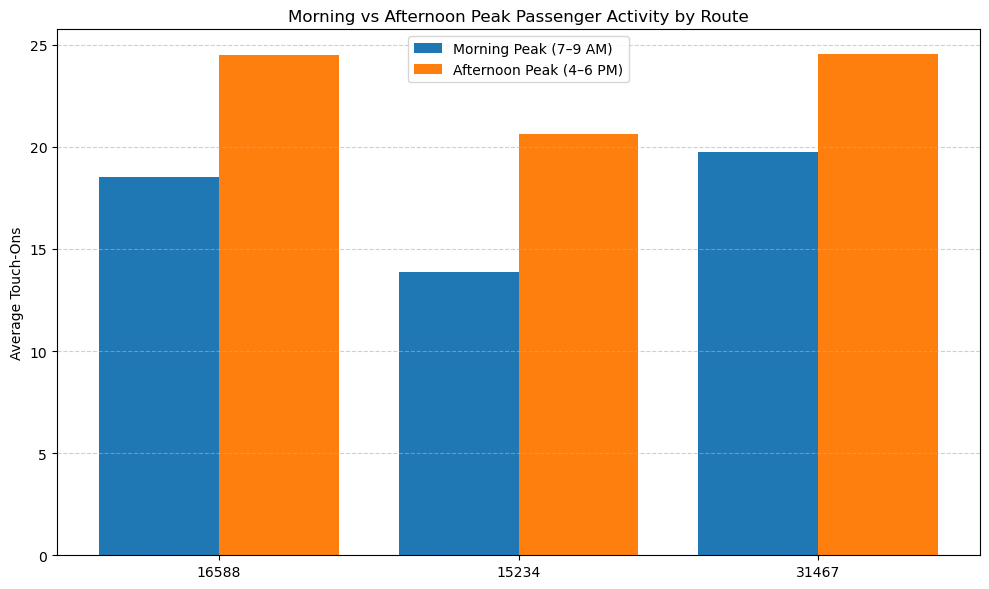

In [18]:
# Plotting morning vs afternoon peak averages
plt.figure(figsize=(10,6))

x = range(len(peak_df))

plt.bar([i - 0.2 for i in x], peak_df["morning_peak_avg"], width=0.4, label="Morning Peak (7–9 AM)")
plt.bar([i + 0.2 for i in x], peak_df["afternoon_peak_avg"], width=0.4, label="Afternoon Peak (4–6 PM)")

plt.xticks(x, peak_df["route_id"])
plt.ylabel("Average Touch-Ons")
plt.title("Morning vs Afternoon Peak Passenger Activity by Route")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


The comparison of morning and afternoon peak activity reveals a consistent pattern across all three tram routes, with each route showing higher touch-on volumes in the afternoon peak (4–6 PM) than in the morning peak (7–9 AM). This aligns with typical commuter behaviour in Melbourne, where outbound travel in the late afternoon tends to be more dispersed and heavier than inbound travel in the morning. However, Route 31467 stands out as unusually busy, recording the highest passenger volumes in both peaks and exhibiting the strongest afternoon surge, suggesting it serves a major high-demand corridor. In contrast, Route 15234 shows significantly lower touch-on activity across both periods, indicating a lighter-use route with fewer major trip generators. Route 16588 presents a moderate, expected commuter pattern without notable deviations. Overall, Route 31467 displays the most distinctive behaviour due to its disproportionately high peak-period demand.

## Conclusion:
This analysis demonstrates how Myki transaction data can be transformed into meaningful insights about tram usage patterns across Melbourne’s network. By successfully integrating touch-on and touch-off records with stop location data, we produced a unified dataset that allowed detailed examination of both spatial and temporal passenger behaviour. The busiest stops and routes clearly correspond to major commuter corridors and activity centres, highlighting the central role of the CBD and university precincts in driving demand. Hourly touch-on trends revealed a distinct bi-modal pattern consistent with traditional work and study travel, with sharp peaks in the morning and even stronger surges in the late afternoon. Comparing these peak windows across routes showed that while most follow the expected commuter rhythm, some corridors—such as Route 31467—exhibit disproportionately high evening activity, reflecting corridor-specific travel dynamics. Overall, the assignment illustrates the value of operational data in understanding passenger flows, identifying high-demand locations, and supporting evidence-based transport planning.